# 05 — Análisis por circuito — MGCECDL

Flujo **en memoria** (sin guardar CSVs intermedios), equivalente al cuaderno inferencia:

1. Cargar el dataset filtrado al circuito y período.
2. Configurar Kernel SHAP bajo demanda para el modelo MGCECDL de clasificación más reciente.
3. Aplicar tres escenarios Top-97:
   - Top-97 por `UITI_VANO_PROM` en período completo.
   - Top-97 por frecuencia (`N_APARICIONES`) en período completo.
   - Top-97 por `UITI_VANO_PROM` sobre las fechas de interés concatenadas.
4. Para cada escenario: gráfico de barras de variables, radar por modos y grafo interactivo de variables relevantes.

Se reutilizan las mismas funciones de agregación, modos y gráficos del cuaderno inferencia; solo cambia el modelo usado para las predicciones SHAP.


In [1]:
import importlib
import io
import os
import shutil
import subprocess
import sys
import warnings
from contextlib import redirect_stdout
from pathlib import Path

import numpy as np
import pandas as pd

REPO_URL = "https://github.com/jclugor/chec-local-uiti-vano-interpreter.git"
REPO_NAME = "chec-local-uiti-vano-interpreter"

_cwd = Path.cwd().resolve()
_project_candidate = None
for _candidate in (_cwd, *_cwd.parents):
    if (_candidate / "src" / "chec_impacto").exists():
        _project_candidate = _candidate
        break
if _project_candidate is None:
    _working_root = Path("/kaggle/working") if Path("/kaggle/working").exists() else _cwd
    _clone_dir = _working_root / REPO_NAME
    if not _clone_dir.exists():
        subprocess.run(["git", "clone", REPO_URL, str(_clone_dir)], check=True)
    _project_candidate = _clone_dir.resolve()

_BOOTSTRAP_SRC_PATH = _project_candidate / "src"
if str(_BOOTSTRAP_SRC_PATH) not in sys.path:
    sys.path.insert(0, str(_BOOTSTRAP_SRC_PATH))

from chec_impacto.notebook_support import add_src_to_path, ensure_lfs_data, install_project_requirements, resolve_project_root

PROJECT_ROOT = resolve_project_root(repo_name=REPO_NAME, repo_url=REPO_URL)
install_project_requirements(PROJECT_ROOT)
ensure_lfs_data(PROJECT_ROOT)
SRC_PATH = add_src_to_path(PROJECT_ROOT)

os.chdir(PROJECT_ROOT)
DATA_DIR = PROJECT_ROOT / "data"
print("PROJECT_ROOT:", PROJECT_ROOT)
print("DATA_DIR:", DATA_DIR)


Updated Git hooks.
Git LFS initialized.
PROJECT_ROOT: /Users/diego/Desktop/Proyectos/chec-local-uiti-vano-interpreter
DATA_DIR: /Users/diego/Desktop/Proyectos/chec-local-uiti-vano-interpreter/data


## Parámetros

In [2]:
from chec_impacto.training import latest_model_path as _modelo_mas_reciente
CIRCUITO_INTERES         = "DON23L13"
FECHA_INICIO             = "2025-11-01 00:00:01"
FECHA_FIN                = "2026-04-30 21:53:40"
FECHAS_INTERES           = ["2025-11-16", "2025-12-01", "2026-02-02", "2026-03-02", "2026-05-15"]

TOP_N_VANOS              = 97
TOP_K_VARS               = 20
RANDOM_STATE             = 42
SHAP_BACKGROUND_SIZE     = 40
SHAP_NSAMPLES            = 80
SHAP_BATCH_SIZE          = 512
SHAP_RANDOM_STATE        = 42
FILTRO_UITI_MAX          = None
VENTANA_CLIMATICA_HORAS  = 12

DATASET_PATH             = DATA_DIR / "Indicadores_vano_v3.csv"
VARIABLES_SELECCION_PATH = DATA_DIR / "Variables_seleccion.xlsx"
OPTUNA_STUDY_PATH        = DATA_DIR / "optuna" / "mgcecdl_classification_feature_attention_params.journal"
MODEL_PATH = _modelo_mas_reciente(DATA_DIR / "models", "mgcecdl_classifier_best.zip")

for _p in [DATASET_PATH, VARIABLES_SELECCION_PATH, MODEL_PATH]:
    if not _p.exists():
        raise FileNotFoundError(f"No encontrado: {_p}")


## 1. Carga y filtrado

Se procesa el dataset completo, se aplica el filtro de circuito + período y se trabaja **solo con esas filas** en adelante.

In [3]:
from chec_impacto.data import preparar_splits_estratificados, procesar_dataset_completo
from chec_impacto.training import escalar_features_minmax_mgcecdl, resolve_training_device

DEVICE = resolve_training_device("auto")
print(f"Usando device: {DEVICE}")

with redirect_stdout(io.StringIO()):
    datos = procesar_dataset_completo(
        path_clima=DATASET_PATH,
        path_variables_seleccion=VARIABLES_SELECCION_PATH,
        use_sampling=False,
        min_samples_per_codigo=5,
        target="UITI_VANO",
        filtro_uiti_max=FILTRO_UITI_MAX,
        ventana_climatica_horas=VENTANA_CLIMATICA_HORAS,
    )

X_full_raw = np.asarray(datos["X"], dtype=np.float32)
features   = list(datos["features"])
base_full  = datos["df_original_copy"].copy().reset_index(drop=True)

# MGCECDL se entrenó con features escaladas min-max; se reutiliza el scaler de features.
splits_clf = escalar_features_minmax_mgcecdl(
    preparar_splits_estratificados(
        X_full_raw,
        datos["y"],
        modo="clasificacion",
        random_state=RANDOM_STATE,
    )
)
feature_scaler = splits_clf["feature_scaler"]
X_full = feature_scaler.transform(X_full_raw).astype(np.float32)

fechas_col = pd.to_datetime(base_full["FECHA"], errors="coerce")
mascara = (
    base_full["CIRCUITO"].astype(str).str.strip().eq(CIRCUITO_INTERES)
    & fechas_col.ge(pd.Timestamp(FECHA_INICIO))
    & fechas_col.le(pd.Timestamp(FECHA_FIN))
)
if not mascara.any():
    raise ValueError(
        f"Sin datos para {CIRCUITO_INTERES} entre {FECHA_INICIO} y {FECHA_FIN}."
    )

# X e índices filtrados — referencia 0..N-1 en adelante
X    = X_full[mascara.to_numpy()]                         # (N, n_features), escalado MGCECDL
base = base_full[mascara].copy().reset_index(drop=True)   # índice 0..N-1
base["_FECHA_DIA"] = fechas_col[mascara].dt.strftime("%Y-%m-%d").values

print(f"Circuito     : {CIRCUITO_INTERES}")
print(f"Período      : {FECHA_INICIO}  →  {FECHA_FIN}")
print(f"Eventos      : {len(X):,}")
print(f"Vanos únicos : {base['FID_VANO'].nunique():,}")
print(f"Features     : {len(features)}")


Usando device: mps
Dataset original: X=(159470, 70), y=(159470, 1)
Splits generados -> Train: (102060, 70), Valid: (25516, 70), Test: (31894, 70)
Modo objetivo: clasificacion

Distribución de clases para estratificación:
Original: [39868 39867 39867 39868]
Train:    [25515 25515 25515 25515]
Valid:    [6379 6379 6379 6379]
Test:     [7974 7973 7973 7974]
Circuito     : DON23L13
Período      : 2025-11-01 00:00:01  →  2026-04-30 21:53:40
Eventos      : 9,418
Vanos únicos : 845
Features     : 70


## 2. Modelo MGCECDL


In [4]:
from chec_impacto.training import cargar_estudio_optuna_mgcecdl, cargar_modelo_mgcecdl, predict_classification

with warnings.catch_warnings(), redirect_stdout(io.StringIO()):
    warnings.simplefilter("ignore")
    modelo = cargar_modelo_mgcecdl(str(MODEL_PATH), device=DEVICE)

if OPTUNA_STUDY_PATH.exists():
    study_clf = cargar_estudio_optuna_mgcecdl(OPTUNA_STUDY_PATH, "clasificacion")
    GRAFO_ESTIMADO_RBF_SIGMA = float(study_clf.best_params.get("rbf_sigma", 1.0))
else:
    warnings.warn(
        f"No existe {OPTUNA_STUDY_PATH}; se usara rbf_sigma=1.0 para el grafo estimado.",
        RuntimeWarning,
    )
    GRAFO_ESTIMADO_RBF_SIGMA = 1.0

print(f"Modelo: {type(modelo).__name__} | {MODEL_PATH.name}")
print(f"rbf_sigma para grafo estimado: {GRAFO_ESTIMADO_RBF_SIGMA}")


Modelo: MGCECDLClassifier | mgcecdl_classifier_best.zip
rbf_sigma para grafo estimado: 4.668017104669593


## 3. Kernel SHAP — configuración bajo demanda

Kernel SHAP se configura con la misma clase usada por inferencia, pero sobre un
wrapper `predict_proba` que llama al clasificador MGCECDL. Las atribuciones se
calculan **solo para los eventos que entren en cada escenario**. Para el ranking
por fila se usa `abs(SHAP)` y se guarda internamente en `_TOP_VARS`.


In [5]:
from chec_impacto.interpretability.circuit_analysis import KernelShapTopVarsExtractor
from chec_impacto.interpretability.circuit_analysis import MGCECDLClassifierShapAdapter




modelo_shap = MGCECDLClassifierShapAdapter(modelo, DEVICE)
shap_extractor = KernelShapTopVarsExtractor(
    model=modelo_shap,
    X=X,
    features=features,
    top_k=TOP_K_VARS,
    background_size=SHAP_BACKGROUND_SIZE,
    nsamples=SHAP_NSAMPLES,
    batch_size=SHAP_BATCH_SIZE,
    random_state=SHAP_RANDOM_STATE,
)
print(
    f"Kernel SHAP configurado | fondo={shap_extractor.n_background} "
    f"| nsamples={SHAP_NSAMPLES} | batch={SHAP_BATCH_SIZE}"
)


Kernel SHAP configurado | fondo=40 | nsamples=80 | batch=512


## 4. Agregación base por vano

La agregación por vano se importa desde `chec_impacto.interpretability.circuit_analysis`.
Cuando un dataframe ya tiene `_TOP_VARS`, la misma función puede adjuntar
`RELEVANCIA_VARS` por regla de Borda.


In [6]:
from chec_impacto.interpretability.circuit_analysis import agrupar_por_vano


## 5. Top-97 y gráficos por escenario

Los tres escenarios usan la misma metodología de agregación por vano, Kernel SHAP
como fuente de atribución, Borda ponderado por `abs(SHAP)`, y normalización min-max
0-1 justo antes de graficar. Cada escenario produce barras, radar y un grafo interactivo HTML de la matriz estimada por reconstruccion del modelo.


In [7]:
# Tabla base por vano para el período completo.
tabla_periodo = agrupar_por_vano(base)

n_top = min(TOP_N_VANOS, len(tabla_periodo))
print(f"Top-N configurado : {TOP_N_VANOS}")
print(f"Top-N efectivo    : {n_top}")
print(f"Vanos período     : {len(tabla_periodo)}")


Top-N configurado : 97
Top-N efectivo    : 97
Vanos período     : 845


## 6. Configuración común de modos y gráficos

La construcción de modos y la generación de barras/radar/grafo interactivo estimado se importan desde
`chec_impacto.interpretability.circuit_analysis`.


In [8]:
import inspect
import importlib
import chec_impacto.interpretability.circuit_analysis as circuit_analysis

circuit_analysis = importlib.reload(circuit_analysis)
construir_modos_chec = circuit_analysis.construir_modos_chec
graficar_barras_y_radar = circuit_analysis.graficar_barras_y_radar

if "graph_source" not in inspect.signature(graficar_barras_y_radar).parameters:
    raise RuntimeError(
        "La funcion graficar_barras_y_radar cargada no tiene soporte de grafo estimado. "
        "Reinicia el kernel y ejecuta el cuaderno desde la primera celda."
    )

MODOS = construir_modos_chec(features, VARIABLES_SELECCION_PATH)
print(f"Modos configurados: {len(MODOS)}")

GRAPH_OUTPUT_DIR = PROJECT_ROOT / "reports" / "mgcecdl-results" / "interactive_graphs"
GRAPH_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
print(f"Grafos interactivos: {GRAPH_OUTPUT_DIR}")
print("graficar_barras_y_radar:", inspect.signature(graficar_barras_y_radar))


Modos configurados: 6
Grafos interactivos: /Users/diego/Desktop/Proyectos/chec-local-uiti-vano-interpreter/reports/mgcecdl-results/interactive_graphs
graficar_barras_y_radar: (df_eventos, titulo, circuito, features, modos, shap_extractor, top_k=20, graph_adjacency_matrix=None, graph_preserved_edges=None, graph_output_dir=None, graph_output_name=None, graph_source='expert', estimated_graph_model=None, X_model=None, estimated_graph_rbf_sigma=1.0, estimated_graph_device='cpu', estimated_graph_batch_size=1024)


## 7. Top-97 por UITI_VANO — período completo


Top-97 por UITI_VANO — período completo | eventos: 359 | vanos: 97


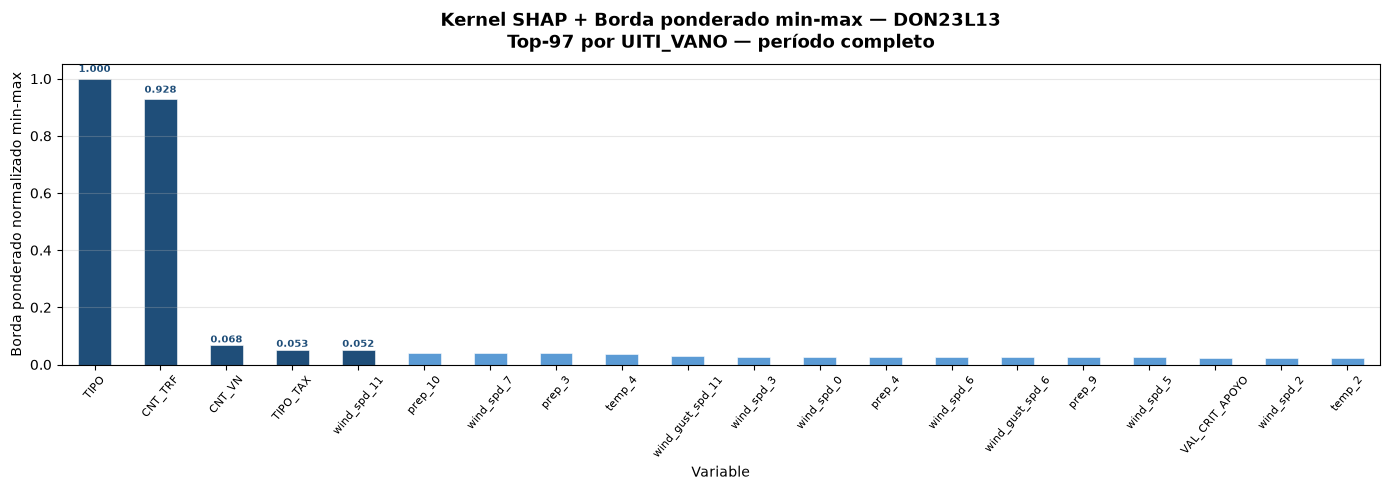

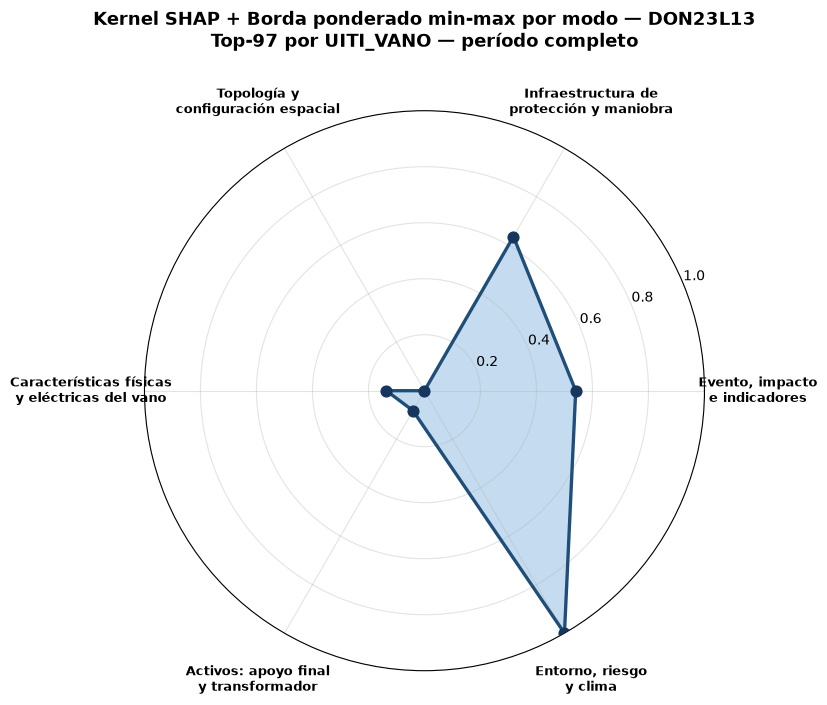

Grafo interactivo guardado en: /Users/diego/Desktop/Proyectos/chec-local-uiti-vano-interpreter/reports/mgcecdl-results/interactive_graphs/top_uiti_periodo.html


{'eventos':       CIRCUITO    FID_SW COD_EQ_PROTEGE  FID_VANO  T_USUS_EQ_PROT   LVSW  \
 41    DON23L13  20477790         L12923  20475385              52  0.196   
 42    DON23L13  20477790         L12923  20475828              52  0.399   
 43    DON23L13  20477790         L12923  20476148              52  0.527   
 64    DON23L13  20477852         L12556  20475435              77  4.669   
 65    DON23L13  20477852         L12556  20475435              77  4.669   
 ...        ...       ...            ...       ...             ...    ...   
 9053  DON23L13  31433833         L12185  20475974              57  5.443   
 9054  DON23L13  31433833         L12185  20475974              57  5.443   
 9055  DON23L13  31433833         L12185  20475974              57  5.443   
 9056  DON23L13  31433833         L12185  20475974              57  5.443   
 9057  DON23L13  31433833         L12185  20475974              57  5.443   
 
       CNT_VN  CNT_VN_SW               FECHA  DURACION  ...  cl

In [9]:
tabla_top_uiti = (
    tabla_periodo
    .sort_values("UITI_VANO_PROM", ascending=False, kind="stable")
    .head(n_top)
    .reset_index(drop=True)
)
ids_top_uiti = tabla_top_uiti["FID_VANO"].tolist()
base_top_uiti = base[base["FID_VANO"].isin(ids_top_uiti)].copy()

graficar_barras_y_radar(
    base_top_uiti,
    f"Top-{n_top} por UITI_VANO — período completo",
    circuito=CIRCUITO_INTERES,
    features=features,
    modos=MODOS,
    shap_extractor=shap_extractor,
    top_k=TOP_K_VARS,
    graph_source="estimated",
    estimated_graph_model=modelo,
    X_model=X,
    estimated_graph_rbf_sigma=GRAFO_ESTIMADO_RBF_SIGMA,
    estimated_graph_device=DEVICE,
    estimated_graph_batch_size=SHAP_BATCH_SIZE,
    graph_output_dir=GRAPH_OUTPUT_DIR,
    graph_output_name="top_uiti_periodo.html",
)


## 8. Top-97 por frecuencia — período completo


Top-97 por frecuencia — período completo | eventos: 4,410 | vanos: 97


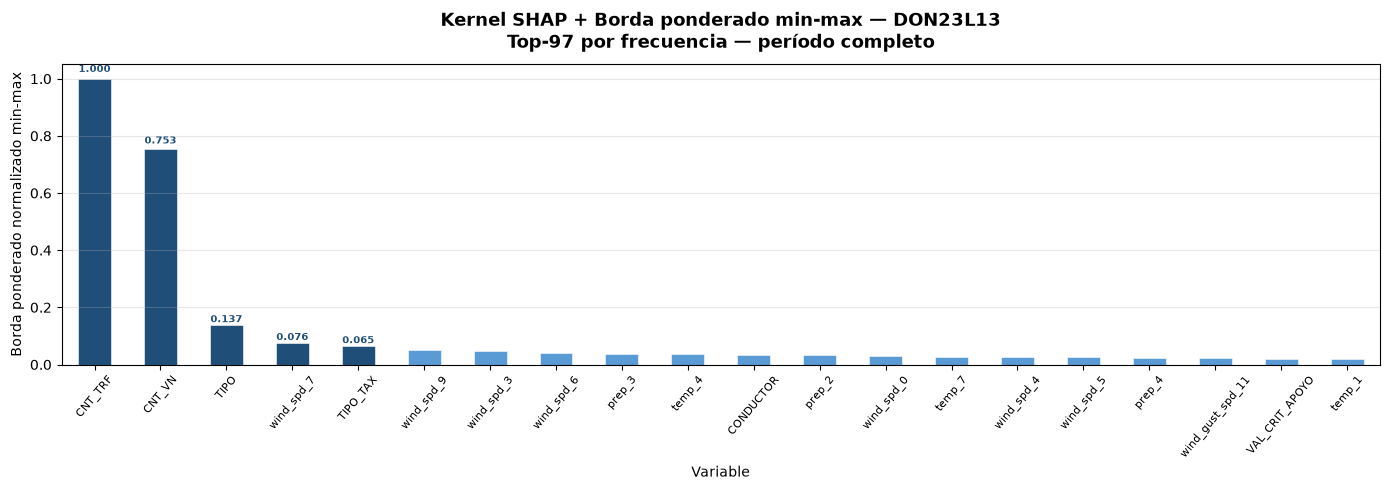

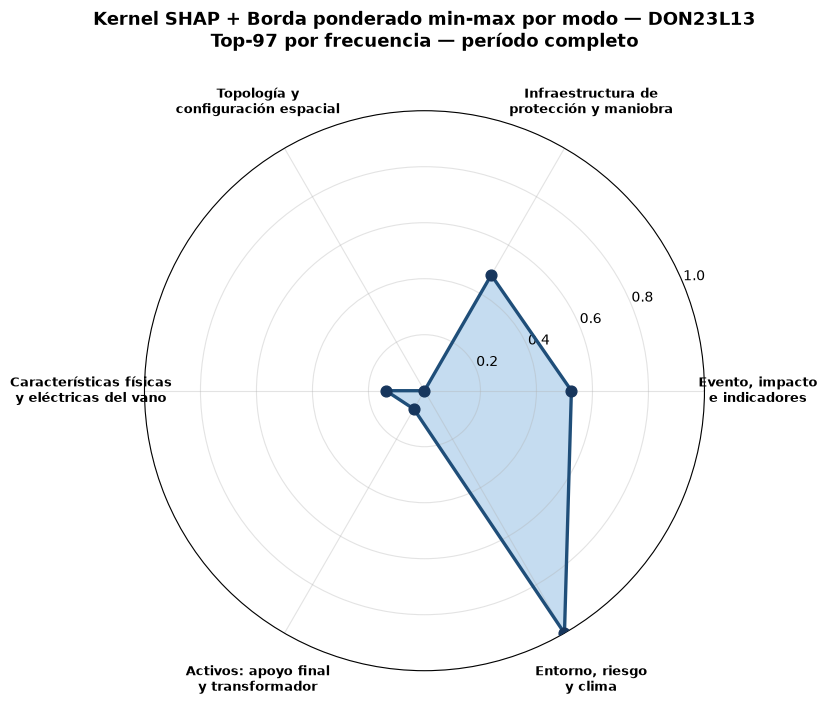

Grafo interactivo guardado en: /Users/diego/Desktop/Proyectos/chec-local-uiti-vano-interpreter/reports/mgcecdl-results/interactive_graphs/top_frecuencia_periodo.html


{'eventos':       CIRCUITO     FID_SW COD_EQ_PROTEGE   FID_VANO  T_USUS_EQ_PROT   LVSW  \
 498   DON23L13   47110122       2DN13R02   20475698             444  8.401   
 499   DON23L13   47110122       2DN13R02   20475698             444  8.401   
 500   DON23L13   47110122       2DN13R02   20475698             444  8.401   
 501   DON23L13   47110122       2DN13R02   20475698             444  8.401   
 502   DON23L13   47110122       2DN13R02   20475698             444  8.401   
 ...        ...        ...            ...        ...             ...    ...   
 7620  DON23L13  357513412       DON23L13  357615557            1139  7.207   
 7621  DON23L13  357513412       DON23L13  357615557            1139  7.207   
 7622  DON23L13  357513412       DON23L13  357615557            1139  7.207   
 7623  DON23L13  357513412       DON23L13  357615557            1139  7.207   
 7624  DON23L13  357513412       DON23L13  357615557            1139  7.207   
 
       CNT_VN  CNT_VN_SW               

In [10]:
tabla_top_frecuencia = (
    tabla_periodo
    .sort_values(["N_APARICIONES", "UITI_VANO_PROM"], ascending=[False, False], kind="stable")
    .head(n_top)
    .reset_index(drop=True)
)
ids_top_frecuencia = tabla_top_frecuencia["FID_VANO"].tolist()
base_top_frecuencia = base[base["FID_VANO"].isin(ids_top_frecuencia)].copy()

graficar_barras_y_radar(
    base_top_frecuencia,
    f"Top-{n_top} por frecuencia — período completo",
    circuito=CIRCUITO_INTERES,
    features=features,
    modos=MODOS,
    shap_extractor=shap_extractor,
    top_k=TOP_K_VARS,
    graph_source="estimated",
    estimated_graph_model=modelo,
    X_model=X,
    estimated_graph_rbf_sigma=GRAFO_ESTIMADO_RBF_SIGMA,
    estimated_graph_device=DEVICE,
    estimated_graph_batch_size=SHAP_BATCH_SIZE,
    graph_output_dir=GRAPH_OUTPUT_DIR,
    graph_output_name="top_frecuencia_periodo.html",
)

## 9. Top-97 por UITI_VANO — fechas de interés concatenadas


Top-97 por UITI_VANO — fechas de interés concatenadas | eventos: 544 | vanos: 97


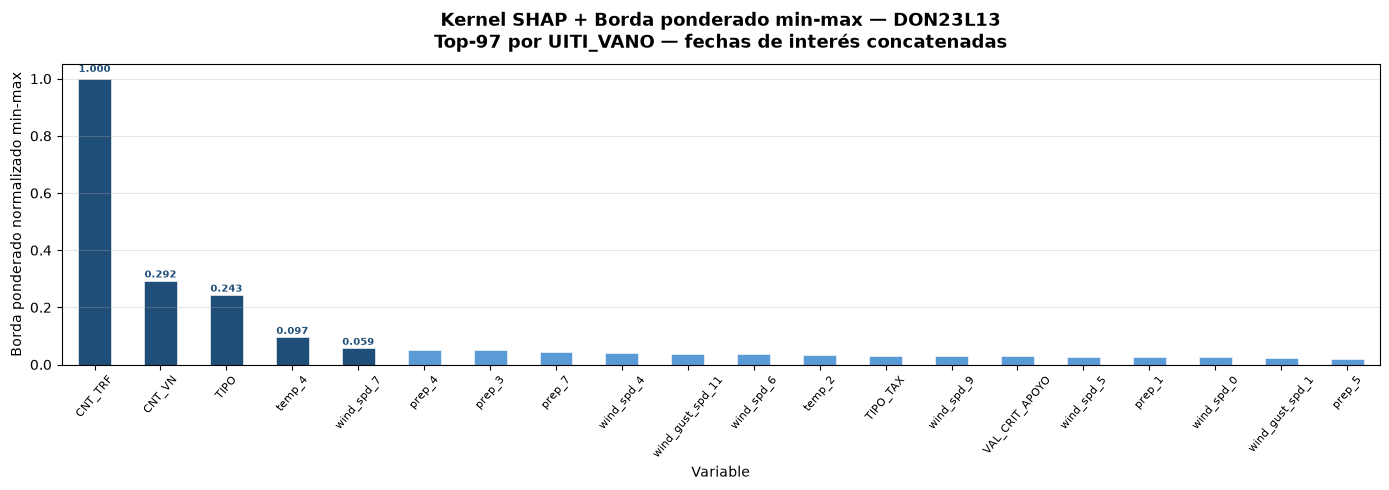

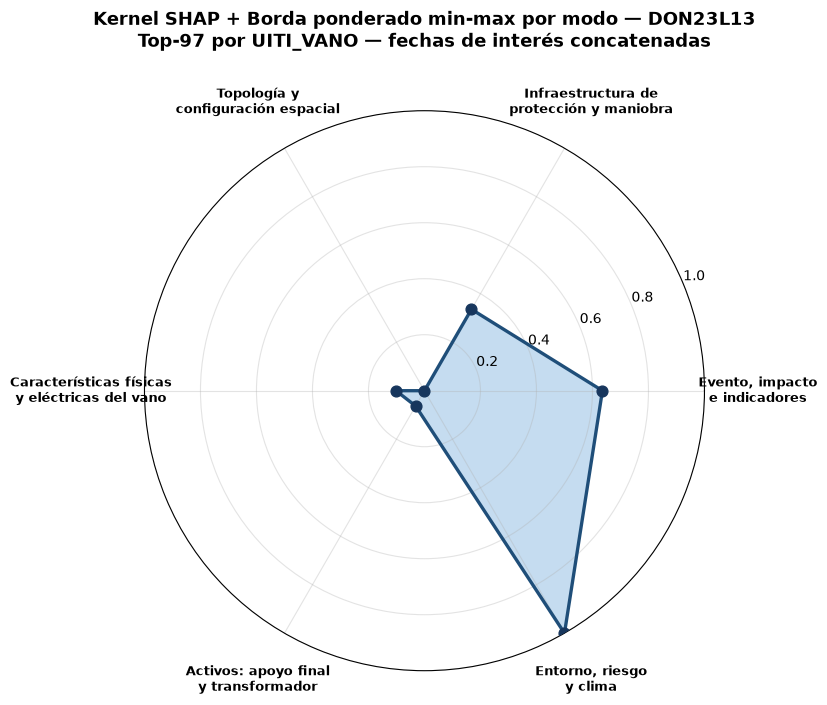

Grafo interactivo guardado en: /Users/diego/Desktop/Proyectos/chec-local-uiti-vano-interpreter/reports/mgcecdl-results/interactive_graphs/top_uiti_fechas.html


{'eventos':       CIRCUITO    FID_SW COD_EQ_PROTEGE  FID_VANO  T_USUS_EQ_PROT   LVSW  \
 2104  DON23L13  20477897       2DN13R01  20475693             106  3.287   
 2105  DON23L13  20477897       2DN13R01  20475693             106  3.287   
 2106  DON23L13  20477897       2DN13R01  20475693             106  3.287   
 2107  DON23L13  20477897       2DN13R01  20475693             106  3.287   
 2108  DON23L13  20477897       2DN13R01  20475693             106  3.287   
 ...        ...       ...            ...       ...             ...    ...   
 8491  DON23L13  43248281         L12847  20476317              88  4.792   
 8492  DON23L13  43248281         L12847  20476317              88  4.792   
 8505  DON23L13  43248281         L12847  20476378              88  2.552   
 8506  DON23L13  43248281         L12847  20476378              88  2.552   
 8507  DON23L13  43248281         L12847  20476378              88  2.552   
 
       CNT_VN  CNT_VN_SW               FECHA  DURACION  ...  cl

In [11]:
base_fechas = base[base["_FECHA_DIA"].isin(FECHAS_INTERES)].copy()
if base_fechas.empty:
    raise ValueError("No hay eventos para las FECHAS_INTERES configuradas.")

tabla_fechas = agrupar_por_vano(base_fechas)
n_top_fechas = min(TOP_N_VANOS, len(tabla_fechas))
tabla_top_fechas = (
    tabla_fechas
    .sort_values("UITI_VANO_PROM", ascending=False, kind="stable")
    .head(n_top_fechas)
    .reset_index(drop=True)
)
ids_top_fechas = tabla_top_fechas["FID_VANO"].tolist()
base_top_fechas = base_fechas[base_fechas["FID_VANO"].isin(ids_top_fechas)].copy()

graficar_barras_y_radar(
    base_top_fechas,
    f"Top-{n_top_fechas} por UITI_VANO — fechas de interés concatenadas",
    circuito=CIRCUITO_INTERES,
    features=features,
    modos=MODOS,
    shap_extractor=shap_extractor,
    top_k=TOP_K_VARS,
    graph_source="estimated",
    estimated_graph_model=modelo,
    X_model=X,
    estimated_graph_rbf_sigma=GRAFO_ESTIMADO_RBF_SIGMA,
    estimated_graph_device=DEVICE,
    estimated_graph_batch_size=SHAP_BATCH_SIZE,
    graph_output_dir=GRAPH_OUTPUT_DIR,
    graph_output_name="top_uiti_fechas.html",
)


## 10. Top-97 por frecuencia — fechas de interés concatenadas


Top-97 por frecuencia — fechas de interés concatenadas | eventos: 798 | vanos: 97


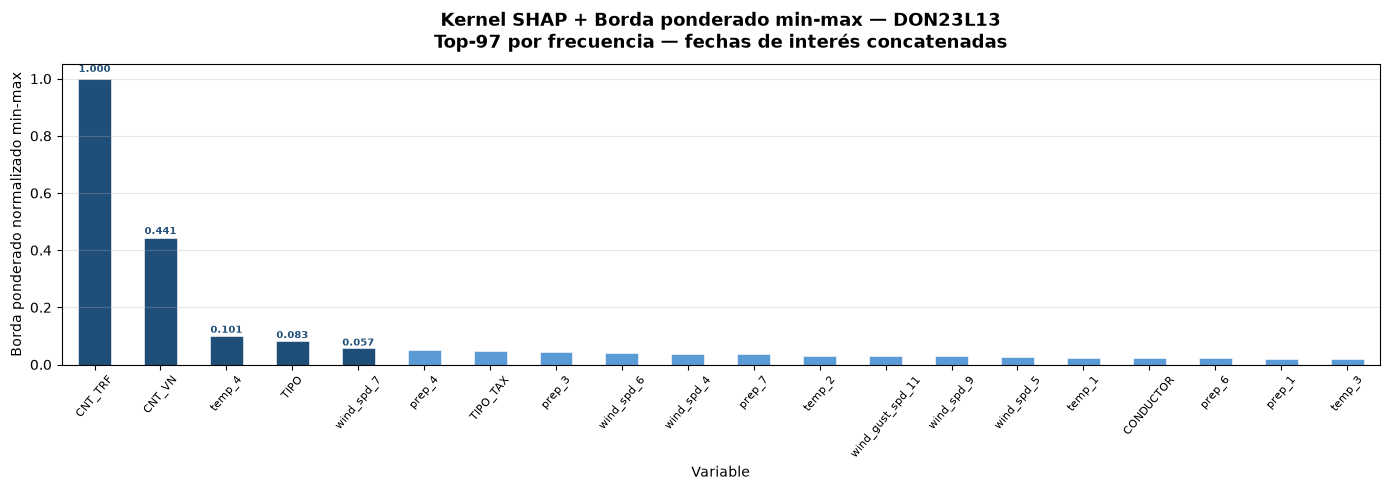

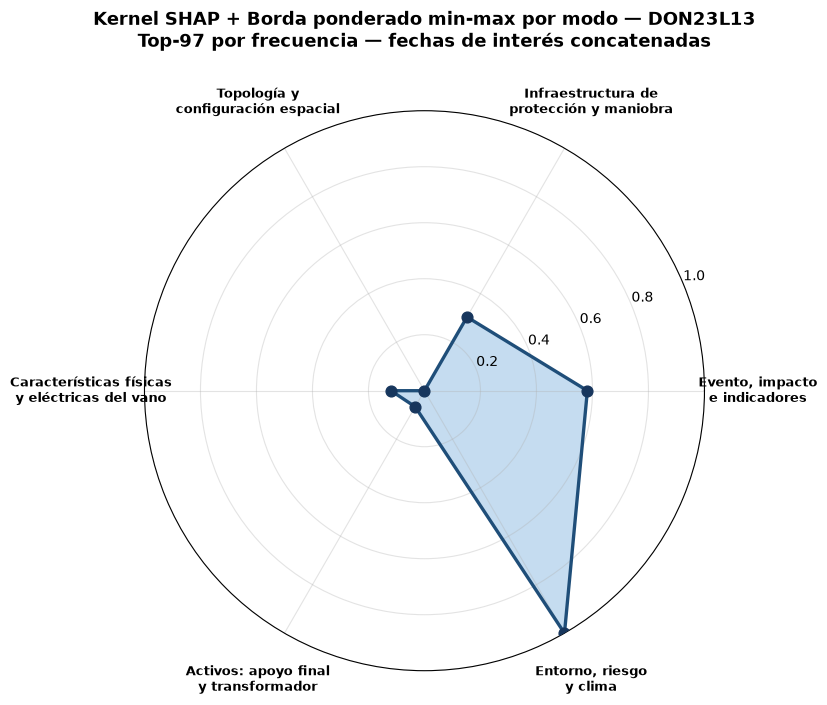

Grafo interactivo guardado en: /Users/diego/Desktop/Proyectos/chec-local-uiti-vano-interpreter/reports/mgcecdl-results/interactive_graphs/top_frecuencia_fechas.html


{'eventos':       CIRCUITO     FID_SW COD_EQ_PROTEGE   FID_VANO  T_USUS_EQ_PROT   LVSW  \
 1456  DON23L13   20477897       2DN13R01   20475150             106  2.241   
 1457  DON23L13   20477897       2DN13R01   20475150             106  2.241   
 1458  DON23L13   20477897       2DN13R01   20475150             106  2.241   
 1459  DON23L13   20477897       2DN13R01   20475150             106  2.241   
 1460  DON23L13   20477897       2DN13R01   20475150             106  2.241   
 ...        ...        ...            ...        ...             ...    ...   
 7603  DON23L13  357513412       DON23L13  357615557            1139  7.207   
 7616  DON23L13  357513412       DON23L13  357615557            1139  7.207   
 7617  DON23L13  357513412       DON23L13  357615557            1139  7.207   
 7618  DON23L13  357513412       DON23L13  357615557            1139  7.207   
 7619  DON23L13  357513412       DON23L13  357615557            1139  7.207   
 
       CNT_VN  CNT_VN_SW               

In [12]:
base_fechas_frecuencia = base[base["_FECHA_DIA"].isin(FECHAS_INTERES)].copy()
if base_fechas_frecuencia.empty:
    raise ValueError("No hay eventos para las FECHAS_INTERES configuradas.")

tabla_fechas_frecuencia = agrupar_por_vano(base_fechas_frecuencia)
n_top_fechas_frecuencia = min(TOP_N_VANOS, len(tabla_fechas_frecuencia))
tabla_top_fechas_frecuencia = (
    tabla_fechas_frecuencia
    .sort_values(["N_APARICIONES", "UITI_VANO_PROM"], ascending=[False, False], kind="stable")
    .head(n_top_fechas_frecuencia)
    .reset_index(drop=True)
)
ids_top_fechas_frecuencia = tabla_top_fechas_frecuencia["FID_VANO"].tolist()
base_top_fechas_frecuencia = base_fechas_frecuencia[
    base_fechas_frecuencia["FID_VANO"].isin(ids_top_fechas_frecuencia)
].copy()

graficar_barras_y_radar(
    base_top_fechas_frecuencia,
    f"Top-{n_top_fechas_frecuencia} por frecuencia — fechas de interés concatenadas",
    circuito=CIRCUITO_INTERES,
    features=features,
    modos=MODOS,
    shap_extractor=shap_extractor,
    top_k=TOP_K_VARS,
    graph_source="estimated",
    estimated_graph_model=modelo,
    X_model=X,
    estimated_graph_rbf_sigma=GRAFO_ESTIMADO_RBF_SIGMA,
    estimated_graph_device=DEVICE,
    estimated_graph_batch_size=SHAP_BATCH_SIZE,
    graph_output_dir=GRAPH_OUTPUT_DIR,
    graph_output_name="top_frecuencia_fechas.html",
)
